# Explainable Campaign Targeting Simulator — Summary

**Corso**: Data Science for Business
**Dataset**: `pytorch-lifestream/retailhero-uplift` (HuggingFace, RetailHero Uplift Modeling)

Questo notebook sintetizza le principali scelte metodologiche e implementative del progetto: analisi preliminare del dataset, costruzione delle feature, gestione del rischio di leakage temporale, confronto tra strategie di uplift modeling e realizzazione dell'applicazione finale tramite API. I risultati discussi derivano dall'esecuzione degli script contenuti in `src/` sul dataset completo, inclusa la tabella `purchases`, composta da circa 45,8 milioni di righe.

## Indice

1. Analisi del dataset
2. Preprocessing e anti-leakage temporale
3. Target, trattamento e LTV
4. Uplift modeling — T-Learner
5. Random Forest: algoritmo scelto
6. Interpretabilità con SHAP
7. Simulazione campagna: uplift-based vs random
8. Predizione sul test set
9. Applicazione: API, frontend e Docker
10. Limiti e sviluppi futuri
11. Conclusioni

## 1. Analisi del dataset

Il dataset è costituito da 5 tabelle. Prima di procedere con il preprocessing, si è ritenuto necessario verificare direttamente struttura, dimensioni, tipologia delle colonne e presenza di valori mancanti, tramite lo script `src/data_audit.py`.

| Tabella | Righe | Colonne | Contenuto |
|---|---:|---:|---|
| `clients` | 400.162 | 5 | Anagrafica cliente: età, genere e date di iscrizione/riscatto |
| `products` | 43.038 | 11 | Informazioni prodotto: categoria, brand, alcol, marca propria |
| `purchases` | 45.786.568 | 13 | Storico transazionale a livello di riga prodotto |
| `uplift_train` | 200.039 | 3 | Clienti con `treatment_flg` e `target` osservati |
| `uplift_test` | 200.123 | 1 | Clienti senza target osservato, oggetto della predizione finale |

**Osservazione rilevante emersa dall'audit**: la colonna `purchase_sum` esprime un valore a livello di transazione, ma compare ripetuta su ogni riga prodotto appartenente allo stesso scontrino. Per evitare una sovrastima della spesa, ogni `transaction_id` è stato considerato una sola volta per ciascun cliente nel calcolo della spesa complessiva.

In [1]:
import pandas as pd

# Cross-tab treatment/target (dati confermati tramite audit del dataset)
audit_summary = pd.DataFrame({
    "treatment_flg": [0, 0, 1, 1],
    "target": [0, 1, 0, 1],
    "count": [39695, 60363, 36342, 63639],
})
audit_summary

,treatment_flg,target,count
0,0,0,39695
1,0,1,60363
2,1,0,36342
3,1,1,63639


## 2. Preprocessing e anti-leakage temporale

La tabella `purchases` copre il periodo compreso tra il 2018-11-21 e il 2019-03-18. Non essendo disponibile, per il dataset in esame, una data di trattamento specifica per singolo cliente, si è adottato un cutoff temporale globale, con l'obiettivo di ridurre il rischio che le feature predittive includano acquisti successivi alla comunicazione della campagna.

Le feature di modeling sono calcolate esclusivamente sulle transazioni antecedenti a:

`max(transaction_datetime) - 14 giorni = 2019-03-04`

La porzione successiva della finestra temporale viene esclusa dal calcolo delle feature predittive, in quanto potenzialmente riconducibile a comportamenti già condizionati dalla campagna stessa. Il LTV proxy, di contro, viene calcolato sull'intero storico disponibile, essendo impiegato come indicatore di business e non come variabile predittiva del target.

In conseguenza dell'applicazione del cutoff, 8.115 clienti risultano privi di transazioni pre-cutoff. Tale condizione è stata gestita mediante:

- un indicatore dedicato, `is_new_customer`;
- imputazione a zero per le variabili di conteggio e di somma;
- un valore sentinella elevato per `recency_days_pre`, in quanto l'assenza di acquisti osservati non è equiparabile a un acquisto recente.

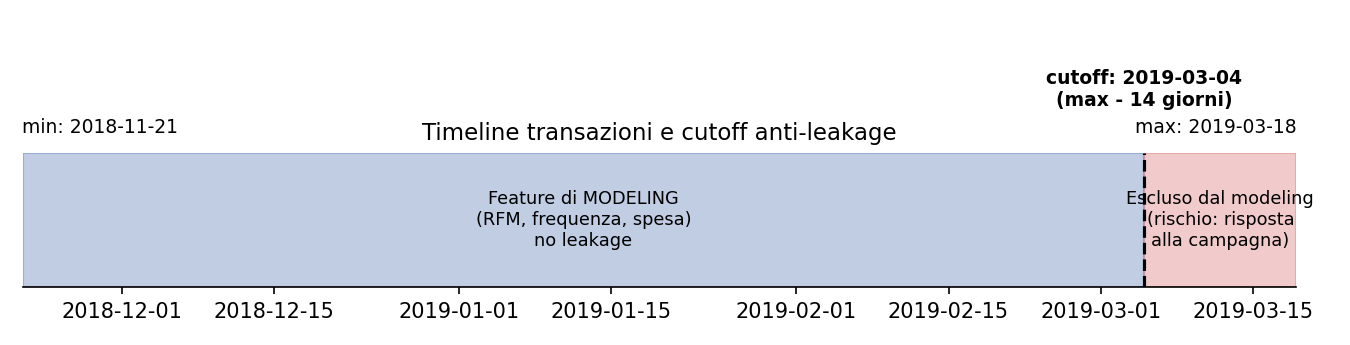

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Date reali confermate tramite audit del dataset
min_dt = datetime(2018, 11, 21, 21, 2, 33)
max_dt = datetime(2019, 3, 18, 23, 40, 3)
cutoff_dt = datetime(2019, 3, 4, 23, 40, 3)  # max_dt - 14 giorni

fig, ax = plt.subplots(figsize=(9, 2.3))
ax.axvspan(min_dt, cutoff_dt, color="#4C72B0", alpha=0.35)
ax.axvspan(cutoff_dt, max_dt, color="#D96C6C", alpha=0.35)
ax.axvline(cutoff_dt, color="black", linewidth=1.5, linestyle="--")
ax.set_xlim(min_dt, max_dt)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.text(min_dt, 1.15, "min: 2018-11-21", ha="left", fontsize=9)
ax.text(max_dt, 1.15, "max: 2019-03-18", ha="right", fontsize=9)
ax.text(cutoff_dt, 1.35, "cutoff: 2019-03-04\n(max - 14 giorni)", ha="center", fontsize=9, fontweight="bold")
ax.text((mdates.date2num(min_dt) + mdates.date2num(cutoff_dt)) / 2, 0.5,
        "Feature di MODELING\n(RFM, frequenza, spesa)\nno leakage", ha="center", va="center", fontsize=8.5)
ax.text((mdates.date2num(cutoff_dt) + mdates.date2num(max_dt)) / 2, 0.5,
        "Escluso dal modeling\n(rischio: risposta\nalla campagna)", ha="center", va="center", fontsize=8.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_title("Timeline transazioni e cutoff anti-leakage", fontsize=11)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()

fig.savefig("reports/leakage_timeline.png", dpi=160, bbox_inches="tight")
plt.show()


## 3. Target, trattamento e LTV

- **Target**: variabile `target` in `uplift_train`, dove il valore 1 indica un acquisto osservato successivamente alla campagna.
- **Treatment**: variabile `treatment_flg` in `uplift_train`, dove il valore 1 indica un cliente esposto alla comunicazione.
- **LTV proxy**: spesa storica complessiva del cliente, calcolata su `purchase_sum` considerando ogni scontrino una sola volta.
- **Clustering LTV**: suddivisione della customer base in 4 fasce mediante quartili.

Si è preferito l'impiego dei quartili rispetto a un algoritmo di clustering quale K-Means in ragione della marcata asimmetria che caratterizza la distribuzione della spesa nel settore retail: i quartili garantiscono infatti gruppi di dimensione comparabile e risultano più agevolmente interpretabili ai fini dell'analisi.

Le soglie ottenute risultano le seguenti:

- q25 = 3146.66
- q50 = 6111.35
- q75 = 11101.92

La distribuzione conseguente risulta sostanzialmente bilanciata sui 400.162 clienti complessivi.

## 4. Uplift modeling — T-Learner

La strategia adottata è quella del T-Learner, che prevede l'addestramento di due modelli distinti: uno sulla popolazione di clienti trattati, l'altro sulla popolazione di controllo.

- `model_treatment` stima `P(target=1 | X, treatment=1)`
- `model_control` stima `P(target=1 | X, treatment=0)`

L'uplift score è definito come:

`uplift_score = p_treatment - p_control`

Ai fini dell'addestramento sono state impiegate esclusivamente le feature pre-cutoff; le colonne `*_full` e `ltv_*` sono state deliberatamente escluse, al fine di evitare la reintroduzione di informazioni calcolate sull'intero periodo storico, con conseguente rischio di leakage.

In [3]:
results = pd.DataFrame({
    "algo": ["random_forest", "logistic_regression", "xgboost", "automl (FLAML)"],
    "auc_treatment": [0.7487, 0.7389, 0.7514, 0.7512],
    "auc_control": [0.7474, 0.7402, 0.7510, 0.7506],
    "qini_coefficient": [131.6035, 121.6062, 93.4255, 104.2787],
    "mean_uplift": [0.0311, 0.0286, 0.0312, 0.0315],
}).sort_values("qini_coefficient", ascending=False)

results


,algo,auc_treatment,auc_control,qini_coefficient,mean_uplift
0,random_forest,0.7487,0.7474,131.6035,0.0311
1,logistic_regression,0.7389,0.7402,121.6062,0.0286
3,automl (FLAML),0.7512,0.7506,104.2787,0.0315
2,xgboost,0.7514,0.7510,93.4255,0.0312


### Osservazione metodologica

Il modello XGBoost presenta l'AUC più elevata sui singoli sotto-modelli (0.7514 per il modello di treatment e 0.7510 per quello di controllo), ma ottiene un Qini coefficient (93.43) inferiore a quello del Random Forest (131.60), che presenta invece valori di AUC leggermente più contenuti (0.7487 e 0.7474).

Questo risultato indica che, nel presente esperimento, una maggiore capacità predittiva dei singoli sotto-modelli non si traduce necessariamente in un migliore ranking dell'effetto incrementale. Nell'ambito dell'uplift modeling, l'obiettivo non consiste solo nella stima accurata della probabilità di acquisto, ma nel corretto ordinamento dei clienti in funzione dell'effetto incrementale atteso della campagna.

Anche la procedura di AutoML, condotta tramite FLAML, ha selezionato XGBoost per entrambi i sotto-modelli, ottenendo un Qini coefficient di 104.28, superiore sia allo XGBoost configurato manualmente sia alla Logistic Regression (121.61). Random Forest resta comunque il modello più efficace secondo la metrica di riferimento adottata nel progetto.

**Modello selezionato: Random Forest, Qini = 131.60.**

## 5. Random Forest: algoritmo scelto

Il modello finale impiega un Random Forest Classifier per entrambi i sotto-modelli del T-Learner:

```python
RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=50,
    n_jobs=-1, random_state=42,
)
```

### Funzionamento

Il Random Forest combina un insieme numeroso di alberi decisionali, ciascuno addestrato su un campione bootstrap differente estratto dal training set; ciascun albero osserva pertanto una versione lievemente diversa dei dati.

A ogni split, inoltre, viene considerato un sottoinsieme casuale delle feature disponibili. Tale meccanismo riduce la correlazione tra gli alberi e rende la media finale delle predizioni più stabile rispetto a quella ottenibile da un singolo albero decisionale.

La predizione finale corrisponde alla media delle probabilità stimate dai 300 alberi che compongono la foresta: tale aspetto risulta rilevante in quanto l'uplift score richiede stime di probabilità continue, non semplici classificazioni binarie.

### Motivazione della scelta nel contesto del progetto

L'uplift medio stimato si attesta su circa 3 punti percentuali, a indicare un segnale relativamente contenuto. Nel T-Learner, l'uplift score deriva dalla differenza tra due probabilità stimate in modo indipendente: qualora i due sotto-modelli presentassero elevata instabilità, anche la differenza finale ne risulterebbe amplificata in termini di varianza.

Il Random Forest, limitando la profondità degli alberi e mediando un numero elevato di predizioni, tende strutturalmente a ridurre la varianza della stima. Tale caratteristica può contribuire a spiegare il motivo per cui, nel presente esperimento, esso abbia conseguito un Qini coefficient superiore rispetto a XGBoost, che pur presentando prestazioni migliori in termini di AUC risulta meno performante nel ranking dell'effetto incrementale.

### Iperparametri principali

- `n_estimators=300`: numero di alberi che compongono la foresta.
- `max_depth=8`: limita la complessità strutturale di ciascun albero.
- `min_samples_leaf=50`: previene la formazione di foglie eccessivamente ridotte, riducendo il rischio di overfitting su casi isolati.

## 6. Interpretabilità con SHAP

Al fine di interpretare il modello selezionato, si è impiegato SHAP TreeExplainer su un campione di 5.000 clienti estratti dal validation set.

Poiché il T-Learner si fonda su due modelli distinti, non è possibile ricavare un valore SHAP esatto per l'uplift score complessivo. Il contributo di ciascuna feature all'uplift è stato pertanto approssimato come differenza tra:

`SHAP_treatment - SHAP_control`

Tale approssimazione non costituisce una spiegazione causale in senso stretto, ma consente comunque di individuare le variabili che maggiormente concorrono ad aumentare o ridurre l'uplift stimato.

In [4]:
shap_importance = pd.read_csv("reports/shap_global_importance.csv")
shap_importance.head(10)

,feature,mean_abs_shap_treatment,mean_abs_shap_control,mean_abs_shap_uplift
0,n_transactions_pre,0.068732,0.074133,0.008168
1,has_redeemed,0.012474,0.006974,0.005500
2,n_product_lines,0.030892,0.033383,0.005255
3,age,0.008701,0.003722,0.005128
4,avg_basket_value_pre,0.025782,0.022419,0.004496
5,total_revenue_pre,0.012573,0.014611,0.003834
6,total_quantity,0.018759,0.021048,0.003823
7,tenure_days,0.011020,0.008603,0.003630
8,n_distinct_products,0.009374,0.012267,0.003347
9,total_iss_sum,0.012563,0.014131,0.002948


![SHAP global importance](reports/shap_global_importance.png)

Le feature di maggiore rilevanza risultano associate alla frequenza e al livello di engagement del cliente: `n_transactions_pre`, `has_redeemed`, `n_product_lines` e `avg_basket_value_pre`. Tale evidenza suggerisce come il modello faccia prevalentemente affidamento su informazioni relative al comportamento storico del cliente, piuttosto che su variabili anagrafiche o isolate.

## 7. Simulazione campagna: uplift-based vs random

Al fine di valutare l'utilità operativa del modello, sono state confrontate due strategie di selezione dei clienti a diversi livelli di budget:

- selezione casuale;
- selezione dei clienti caratterizzati da uplift score più elevato.

Il confronto è condotto sul validation set, che comprende sia clienti trattati sia clienti di controllo. Il guadagno incrementale è stimato secondo la medesima logica sottesa alla curva Qini, mediante il confronto tra le risposte osservate nei due gruppi.

In [5]:
sim = pd.read_csv("reports/campaign_simulation.csv")
sim

,budget_pct,n_selected,incremental_gain_uplift,incremental_gain_random_mean,incremental_gain_random_std,improvement_pct
0,5.0,2500,140.209150,32.975910,19.566604,325.186604
1,10.0,5001,187.977689,78.325722,28.072367,139.994837
2,20.0,10002,323.444026,172.065465,26.563878,87.977306
3,30.0,15003,416.181998,242.642476,53.890379,71.520669
4,40.0,20004,530.489668,321.975828,45.735631,64.760712
5,50.0,25005,614.160087,427.423536,57.471874,43.688879
6,75.0,37507,781.737566,626.419982,55.407817,24.794481
7,100.0,50010,831.065561,831.065561,0.000000,0.000000


![Campaign simulation](reports/campaign_simulation.png)

A parità di budget pari al 20% dei clienti, la selezione uplift-based determina 323 conversioni incrementali stimate, a fronte delle 172 ottenute mediante selezione casuale di pari dimensione: il miglioramento risulta pertanto pari a circa il +88%.

Tale vantaggio si riduce progressivamente all'aumentare del budget, poiché vengono via via inclusi anche clienti caratterizzati da un uplift stimato inferiore. Al 100% di copertura, le due strategie coincidono per costruzione, essendo entrambe rivolte all'intera popolazione.

## 8. Predizione sul test set

Il Random Forest selezionato è stato applicato ai 200.123 clienti appartenenti a `uplift_test`, per i quali il target non risulta disponibile.

Il risultato aggregato è il seguente:

- 172.902 clienti (86,4%) ricevono raccomandazione **Includi**;
- 27.221 clienti (13,6%) ricevono raccomandazione **Escludi**;
- uplift score medio: 0,0308;
- deviazione standard: 0,0316;
- range osservato: da -0,088 a 0,350.

Con riferimento ai clienti classificati come **Includi**, la distribuzione per cluster LTV risulta la seguente:

- Medio-basso: 47.098
- Basso: 45.455
- Medio-alto: 44.732
- Alto: 35.617

I clienti caratterizzati da LTV elevato risultano lievemente sottorappresentati tra i raccomandati. Una possibile interpretazione è che tali clienti, già fortemente attivi, presentino una probabilità di acquisto elevata anche in assenza della campagna, con conseguente riduzione dell'effetto incrementale stimato.

In [6]:
test_predictions = pd.read_csv("reports/test_set_predictions.csv")

print(f"Shape: {test_predictions.shape}")

test_predictions.sort_values('uplift_score', ascending=False).head(10)

Shape: (200123, 7)


,client_id,ltv_proxy,ltv_cluster,p_treatment,p_control,uplift_score,raccomandazione
0,0aaf5cdc03,503.00,Basso,0.582391,0.232177,0.350214,Includi
1,aa004fa8ff,743.62,Basso,0.574169,0.228072,0.346097,Includi
2,b8bf174351,383.93,Basso,0.582313,0.236254,0.346059,Includi
3,e2b17005a0,758.00,Basso,0.582547,0.237739,0.344809,Includi
4,79cf2f9aa0,373.09,Basso,0.588958,0.246285,0.342673,Includi
5,4e1e4a0328,321.00,Basso,0.581264,0.238743,0.342521,Includi
6,c295cff033,832.78,Basso,0.578409,0.238107,0.340302,Includi
7,18dd384f3c,396.00,Basso,0.577878,0.237942,0.339936,Includi
8,a05c3f7b46,258.99,Basso,0.582869,0.246013,0.336856,Includi
9,da03eb3494,503.00,Basso,0.584216,0.247438,0.336778,Includi


## 9. Applicazione: API, frontend e Docker

Il progetto comprende un'applicazione FastAPI che consente l'utilizzo del modello in modalità di serving.

L'endpoint principale, `POST /predict`, riceve le feature aggregate relative a un cliente e restituisce:

- l'uplift score;
- la probabilità stimata in presenza di campagna (`p_treatment`);
- la probabilità stimata in assenza di campagna (`p_control`);
- la raccomandazione operativa;
- il valore di LTV proxy e il relativo cluster;
- le principali variabili SHAP associate alla predizione.

Il frontend consiste in una pagina HTML servita dalla medesima applicazione mediante Jinja2, che consente l'inserimento dei dati del cliente tramite form e la visualizzazione del risultato attraverso una barra comparativa tra `p_control` e `p_treatment`.

L'immagine Docker contiene esclusivamente l'applicazione e i modelli già addestrati: il training rimane distinto dal serving, in coerenza con una più chiara separazione architetturale del progetto.

## 10. Limiti e sviluppi futuri

Il progetto rispetta lo scope definito in fase di proposta, pur presentando alcuni limiti di natura metodologica e implementativa, di seguito discussi.

- **Singolo split train/validation**: la valutazione si basa su uno split stratificato 75/25. L'adozione di una cross-validation consentirebbe stime più stabili delle metriche, aspetto particolarmente rilevante considerata la debolezza del segnale di uplift.

- **Cutoff temporale globale**: il dataset non fornisce una data di trattamento specifica per singolo cliente; il cutoff anti-leakage risulta pertanto uniforme per l'intera popolazione. La disponibilità di date individuali di trattamento consentirebbe la definizione di un cutoff maggiormente puntuale.

- **Impiego del solo T-Learner**: non sono stati confrontati altri meta-learner, quali S-Learner o X-Learner. Il T-Learner è stato adottato in virtù della sua semplicità implementativa, della sua interpretabilità e della coerenza con l'obiettivo del progetto.

- **LTV come proxy**: il dataset non contiene un valore autentico di Customer Lifetime Value; si è pertanto adottata la spesa storica osservata quale proxy. Una stima più completa richiederebbe informazioni aggiuntive relative a margini, retention e comportamento futuro del cliente.



## 11. Conclusioni

Il progetto stima un uplift medio pari a circa 3 punti percentuali, con un response rate del 63,7% tra i clienti trattati e del 60,3% tra i clienti di controllo.

Il confronto tra Logistic Regression, Random Forest, XGBoost e AutoML evidenzia come il modello più performante, secondo il Qini coefficient, sia il Random Forest. Tale scelta non si fonda sull'AUC dei singoli sotto-modelli, bensì sulla capacità di ordinare correttamente i clienti in funzione dell'effetto incrementale atteso della campagna.

La simulazione condotta conferma l'utilità operativa dell'approccio adottato: la selezione dei clienti sulla base dell'uplift score determina un guadagno incrementale superiore rispetto a una selezione casuale, in particolar modo in condizioni di budget ridotto o intermedio.

Sotto il profilo applicativo, il progetto realizza una separazione tra training offline e serving online mediante FastAPI e Docker. Sotto il profilo metodologico, gestisce esplicitamente il rischio di leakage temporale individuato nel corso dell'analisi dei dati.

Tra i possibili sviluppi futuri si segnalano l'impiego di una data di trattamento a livello di singolo cliente, il confronto con ulteriori meta-learner e una stima più completa del Customer Lifetime Value.